In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

df=pd.read_csv('/content/twitter_validation.csv',header=None,encoding='ISO-8859-1')
df

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,â­ï¸ Toronto is the arts and culture capital...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df.columns=['Id','Media','Target','Feedback']
df

,Id,Media,Target,Feedback
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,â­ï¸ Toronto is the arts and culture capital...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df.dtypes

,0
Id,int64
Media,object
Target,object
Feedback,object


In [ ]:
df.shape

(1000, 4)

In [ ]:
df.isna().sum()

,0
Id,0
Media,0
Target,0
Feedback,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
coun=df['Target'].value_counts()

In [ ]:
coun

,count
Target,
Neutral,285
Positive,277
Negative,266
Irrelevant,172


In [ ]:
coun.values

array([285, 277, 266, 172])

<BarContainer object of 4 artists>

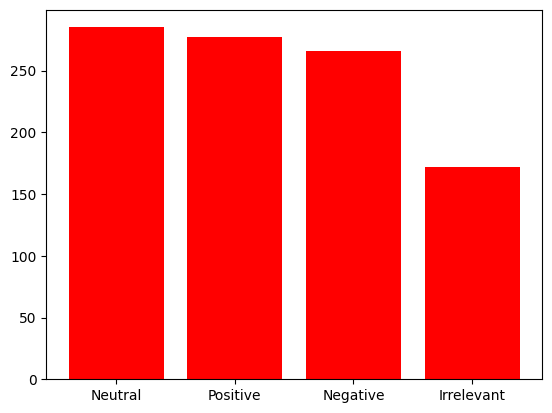

In [ ]:
plt.bar(coun.index,coun.values,color='r')

In [ ]:
df.drop(df.loc[df['Target']=="Irrelevant"].index,inplace=True)

In [ ]:
df

,Id,Media,Target,Feedback
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
5,6273,FIFA,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...,...,...
993,314,Amazon,Negative,Please explain how this is possible! How can t...
994,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df

,Id,Media,Target,Feedback
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...,...,...
823,314,Amazon,Negative,Please explain how this is possible! How can t...
824,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
825,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
826,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df.drop(['Id','Media'],axis=1,inplace=True)

In [ ]:
df

,Target,Feedback
0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Negative,@Microsoft Why do I pay for WORD when it funct...
2,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Neutral,Now the President is slapping Americans in the...
4,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...
823,Negative,Please explain how this is possible! How can t...
824,Positive,Good on Sony. As much as I want to see the new...
825,Positive,Today sucked so itâs time to drink wine n pl...
826,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df['Target']=df['Target'].replace('Positive',1)
df['Target']=df['Target'].replace('Neutral',0)
df['Target']=df['Target'].replace('Negative',-1)
df

/tmp/ipykernel_898/1881698615.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target']=df['Target'].replace('Negative',-1)


,Target,Feedback
0,0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,-1,@Microsoft Why do I pay for WORD when it funct...
2,-1,"CSGO matchmaking is so full of closet hacking,..."
3,0,Now the President is slapping Americans in the...
4,-1,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...
823,-1,Please explain how this is possible! How can t...
824,1,Good on Sony. As much as I want to see the new...
825,1,Today sucked so itâs time to drink wine n pl...
826,1,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df['Target'].unique()

array([ 0, -1,  1])

In [ ]:
text=df.Feedback
text

,Feedback
0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,@Microsoft Why do I pay for WORD when it funct...
2,"CSGO matchmaking is so full of closet hacking,..."
3,Now the President is slapping Americans in the...
4,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...
823,Please explain how this is possible! How can t...
824,Good on Sony. As much as I want to see the new...
825,Today sucked so itâs time to drink wine n pl...
826,Bought a fraction of Microsoft today. Small wins.


In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import TweetTokenizer
tk=TweetTokenizer()
tweets=text.apply(lambda x:tk.tokenize(x)).apply(lambda x:" ".join(x))
tweets


,Feedback
0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,@Microsoft Why do I pay for WORD when it funct...
2,CSGO matchmaking is so full of closet hacking ...
3,Now the President is slapping Americans in the...
4,Hi @EAHelp Iâ   ve had Madeleine McCann in m...
...,...
823,Please explain how this is possible ! How can ...
824,Good on Sony . As much as I want to see the ne...
825,Today sucked so itâ   s time to drink wine n...
826,Bought a fraction of Microsoft today . Small w...


In [ ]:
tweets=tweets.replace('[^a-zA-Z0-9]',' ',regex=True)
tweets

,Feedback
0,BBC News Amazon boss Jeff Bezos rejects clai...
1,Microsoft Why do I pay for WORD when it funct...
2,CSGO matchmaking is so full of closet hacking ...
3,Now the President is slapping Americans in the...
4,Hi EAHelp I ve had Madeleine McCann in m...
...,...
823,Please explain how this is possible How can ...
824,Good on Sony As much as I want to see the ne...
825,Today sucked so it s time to drink wine n...
826,Bought a fraction of Microsoft today Small w...


In [ ]:
from nltk.tokenize import word_tokenize
ts=tweets.apply(lambda x:' '.join(w for w in word_tokenize(x) if len(w)>=3))
tweets

,Feedback
0,BBC News Amazon boss Jeff Bezos rejects clai...
1,Microsoft Why do I pay for WORD when it funct...
2,CSGO matchmaking is so full of closet hacking ...
3,Now the President is slapping Americans in the...
4,Hi EAHelp I ve had Madeleine McCann in m...
...,...
823,Please explain how this is possible How can ...
824,Good on Sony As much as I want to see the ne...
825,Today sucked so it s time to drink wine n...
826,Bought a fraction of Microsoft today Small w...


In [ ]:
from nltk.stem import SnowballStemmer
data=SnowballStemmer('english')
tweets=tweets.apply(lambda x:[data.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x:' '.join(x))
tweets

,Feedback
0,bbc news amazon boss jeff bezo reject claim co...
1,microsoft whi do i pay for word when it functi...
2,csgo matchmak is so full of closet hack it s a...
3,now the presid is slap american in the face th...
4,hi eahelp i ve had madelein mccann in my cella...
...,...
823,pleas explain how this is possibl how can they...
824,good on soni as much as i want to see the new ...
825,today suck so it s time to drink wine n play b...
826,bought a fraction of microsoft today small win


In [ ]:
from nltk.corpus import stopwords
wordd=stopwords.words('english')
tweets = tweets.apply(lambda x: ' '.join([w for w in word_tokenize(x) if w.lower() not in wordd]))

tweets

,Feedback
0,bbc news amazon boss jeff bezo reject claim co...
1,microsoft whi pay word function poor samsungus...
2,csgo matchmak full closet hack truli aw game
3,presid slap american face realli commit unlaw ...
4,hi eahelp madelein mccann cellar past 13 year ...
...,...
823,pleas explain possibl let compani overcharg sc...
824,good soni much want see new ps5 go right much ...
825,today suck time drink wine n play borderland s...
826,bought fraction microsoft today small win


In [ ]:
#Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
vec=TfidfVectorizer()
train_data=vec.fit_transform(tweets)
train_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11034 stored elements and shape (828, 3927)>

In [ ]:
y=df['Target'].values
y

array([ 0, -1, -1,  0, -1,  1,  1,  1, -1,  1,  1, -1,  0, -1,  1,  1, -1,
        1, -1, -1,  0, -1,  0,  0, -1, -1,  1,  1, -1,  1, -1,  0,  0,  1,
        0,  1,  0,  0,  0,  1,  0, -1, -1, -1,  0,  1, -1, -1,  1,  1,  1,
        1,  1, -1, -1,  1,  1, -1,  0, -1,  0, -1,  1, -1, -1,  1,  1,  1,
        0,  0,  0,  1,  1,  0,  1,  0, -1, -1,  0,  0, -1,  1, -1, -1, -1,
        0,  1,  0, -1,  1,  1,  0,  1,  0,  1, -1,  0,  0,  0, -1,  0, -1,
        0,  0,  1,  1,  0, -1, -1,  1, -1,  0, -1,  1,  0, -1,  0,  1,  0,
        1,  1,  0,  0,  0,  0,  1,  0,  1,  1, -1,  0,  0,  0,  0, -1,  0,
        1, -1,  0, -1,  0, -1, -1, -1,  1,  1,  1,  0,  0,  1,  0,  0,  0,
        1,  0, -1, -1,  0,  1,  1,  0,  1,  1,  0,  0, -1, -1, -1, -1,  1,
        0,  0,  1,  1,  1,  1, -1,  1,  1,  0, -1, -1, -1,  1,  1, -1, -1,
        1,  1, -1,  1,  1, -1,  1,  0, -1,  0,  0,  1, -1,  1,  1,  0,  1,
       -1, -1,  1,  1,  1,  1,  0,  0,  1, -1,  0,  1,  0, -1,  0,  0, -1,
        1,  1, -1,  0,  1

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(train_data,y,test_size=0.20,random_state=42)
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8852 stored elements and shape (662, 3927)>

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
y_pred

array([-1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1,
        0, -1, -1, -1,  0,  0,  1, -1,  1, -1, -1,  0,  1, -1,  1, -1, -1,
        1, -1,  0, -1, -1, -1, -1,  1,  0,  1,  1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1,  0,  1, -1,  0,  0,  1, -1,  0,  0, -1,  0,  1,  0,
       -1, -1, -1, -1,  0,  1,  1, -1, -1, -1,  1,  1, -1, -1, -1, -1,  0,
       -1, -1,  1,  1, -1,  1, -1, -1, -1,  0,  0,  1,  0, -1, -1, -1,  1,
        0,  0, -1, -1,  1, -1,  0, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1,  1, -1,  1,  0,  1, -1, -1,  0, -1,  0, -1,  1, -1, -1,  1,
       -1, -1, -1,  1,  0,  1,  0, -1,  0, -1,  0, -1,  1, -1, -1,  0,  1,
       -1, -1, -1,  1,  0, -1,  0, -1, -1, -1, -1,  1,  0])

In [ ]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)*100
score

51.80722891566265

In [ ]:
from sklearn.naive_bayes import BernoulliNB
berno=BernoulliNB()
berno.fit(x_train,y_train)
y_pred1=berno.predict(x_test)

In [ ]:
score1=accuracy_score(y_test,y_pred1)*100
score1

56.024096385542165

In [ ]:
from sklearn.svm import SVC
sv=SVC()
sv.fit(x_train,y_train)
y_pred2=sv.predict(x_test)

In [ ]:
score2=accuracy_score(y_test,y_pred2)*100
score2

55.42168674698795

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(criterion='entropy')
dtc.fit(x_train,y_train)
y_pred3=dtc.predict(x_test)

In [ ]:
score3=accuracy_score(y_test,y_pred3) * 100
score3

46.98795180722892

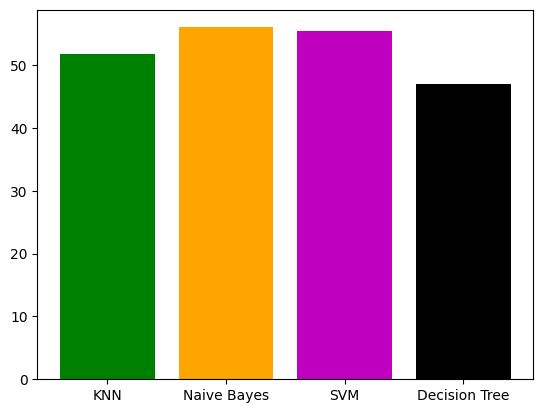

In [ ]:
scores = [score, score1, score2, score3]
models = ['KNN', 'Naive Bayes', 'SVM', 'Decision Tree']

plt.bar(models, scores,color=['g','orange','m','k'])


plt.show()

In [ ]:
review=['This film is good']
p=vec.transform(review)
pred=berno.predict(p)
pred
print("Review",review[0])
print("prediction",pred[0])

Review This film is good
prediction 1
